# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms

from PIL import Image

import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    print(f"[INFO] Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print(f"[INFO] CUDA not available -> using CPU")

[INFO] CUDA not available -> using CPU


# Get the data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Collect Image Paths

In [5]:
DATA_DIR = "/content/drive/MyDrive/BDSoursop_V2/Soursop_V2"

classes = os.listdir(DATA_DIR)

image_paths = []
labels = []

for idx, cls in enumerate(classes):
    cls_path = os.path.join(DATA_DIR, cls)

    for img_name in os.listdir(cls_path):
        if img_name.endswith(".jpg") or img_name.endswith(".png"):
            image_paths.append(os.path.join(cls_path, img_name))
            labels.append(idx)

# Train-Validation-Test Split

In [6]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.3,
    stratify=labels,            # stratify ensures that the proportion of classes in training and testing sets matches the proportion in the original dataset
    random_state=42
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

Custom Dataset Class

In [7]:
class SoursopDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

# Resizing and Transformation

Train Transformation (Augmentation + Resize)

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

Validation/Test Transformation (No Augmentation)

In [9]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Create and Load the Dataset

Create the datasets

In [10]:
train_dataset = SoursopDataset(train_paths, train_labels, transform=train_transform)
val_dataset   = SoursopDataset(val_paths, val_labels, transform=val_transform)
test_dataset  = SoursopDataset(test_paths, test_labels, transform=val_transform)

DataLoader

In [11]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Model Building

Model Architecture

In [12]:
class CNN(nn.Module):
    def __init__(self, num_classes=6):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

Setup Model

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN().to(device)

Optimizer + Loss

In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)   # L2 regularization

# Training Loop + Validation + Metrics

Loss + Optimizer + Scheduler

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=2,
)

Early Stopping Class

In [14]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

Training + Validation Loop

Run Training

In [19]:
def train_model(model, train_loader, val_loader, epochs=20):
    early_stopping = EarlyStopping(patience=5)

    best_val_loss = float('inf')

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        # -------- TRAINING -------- #
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]")

        for images, labels in train_bar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # Update progress bar
            train_bar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{(correct/total):.4f}"
            })

        train_acc = correct / total

        # -------- VALIDATION -------- #
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]")

        with torch.no_grad():
            for images, labels in val_bar:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

                # Update progress bar
                val_bar.set_postfix({
                    "loss": f"{loss.item():.4f}",
                    "acc": f"{(correct/total):.4f}"
                })

        val_acc = correct / total

        # -------- STORE HISTORY -------- #
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # -------- EPOCH SUMMARY -------- #
        print(f"\nEpoch {epoch+1} Summary")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # -------- SCHEDULER -------- #
        scheduler.step(val_loss)

        # -------- SAVE BEST -------- #
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_model.pth")

        # -------- EARLY STOPPING -------- #
        early_stopping(val_loss)
        if early_stopping.stop:
            print("Early stopping triggered.")
            break

    print("Training complete.")

    return train_losses, val_losses, train_accuracies, val_accuracies

In [20]:
train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, epochs=20
)

Epoch 1 [Val]: 100%|██████████| 18/18 [00:09<00:00,  1.92it/s, loss=0.0519, acc=0.9983]



Epoch 1 Summary
Train Loss: 0.7335, Train Acc: 0.9970
Val Loss: 0.0669, Val Acc: 0.9983


Epoch 2 [Val]: 100%|██████████| 18/18 [00:08<00:00,  2.24it/s, loss=0.0282, acc=0.9983]



Epoch 2 Summary
Train Loss: 0.5154, Train Acc: 0.9993
Val Loss: 0.0381, Val Acc: 0.9983


Epoch 3 [Val]: 100%|██████████| 18/18 [00:08<00:00,  2.25it/s, loss=0.0383, acc=0.9983]


...


Epoch 5 Summary
Train Loss: 0.3630, Train Acc: 1.0000
Val Loss: 0.0450, Val Acc: 0.9983


Epoch 6 [Val]: 100%|██████████| 18/18 [00:07<00:00,  2.33it/s, loss=0.0377, acc=0.9983]



Epoch 6 Summary
Train Loss: 0.4397, Train Acc: 0.9989
Val Loss: 0.0429, Val Acc: 0.9983


Epoch 7 [Val]: 100%|██████████| 18/18 [00:09<00:00,  1.97it/s, loss=0.0376, acc=0.9983]


Epoch 7 Summary
Train Loss: 0.3428, Train Acc: 1.0000
Val Loss: 0.0429, Val Acc: 0.9983
Early stopping triggered.
Training complete.


Plot Train and Validation Losses and Accuracy

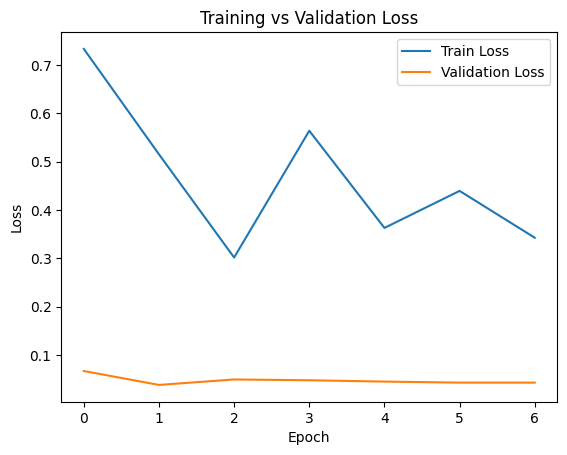

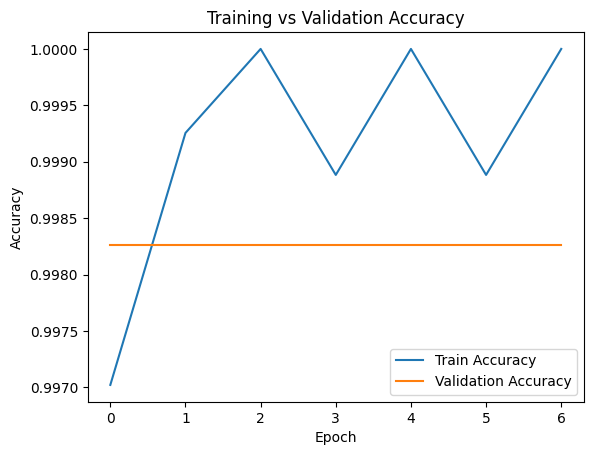

In [22]:
# Loss Curve
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Accuracy Curve
plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# Final Evaluation on Test Data

In [25]:
def evaluate_model(model, test_loader, class_names):
    # -------- LOAD BEST MODEL -------- #
    model.load_state_dict(torch.load("best_model.pth"))
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    test_loss = 0
    correct = 0
    total = 0

    criterion = nn.CrossEntropyLoss()

    # -------- EVALUATION LOOP -------- #
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    # -------- FINAL METRICS -------- #
    test_acc = correct / total
    test_loss = test_loss / len(test_loader)

    print("\n==============================")
    print("FINAL TEST RESULTS")
    print("==============================")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    # -------- CLASSIFICATION REPORT -------- #
    print("\n📄 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # -------- CONFUSION MATRIX -------- #
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


FINAL TEST RESULTS
Test Loss: 0.0002
Test Accuracy: 1.0000

📄 Classification Report:
                     precision    recall  f1-score   support

Cutting Caterpillar       1.00      1.00      1.00        93
     Cutting Weevil       1.00      1.00      1.00        96
           Die Back       1.00      1.00      1.00        98
            Healthy       1.00      1.00      1.00        95
          White Fly       1.00      1.00      1.00        96
             Yellow       1.00      1.00      1.00        98

           accuracy                           1.00       576
          macro avg       1.00      1.00      1.00       576
       weighted avg       1.00      1.00      1.00       576



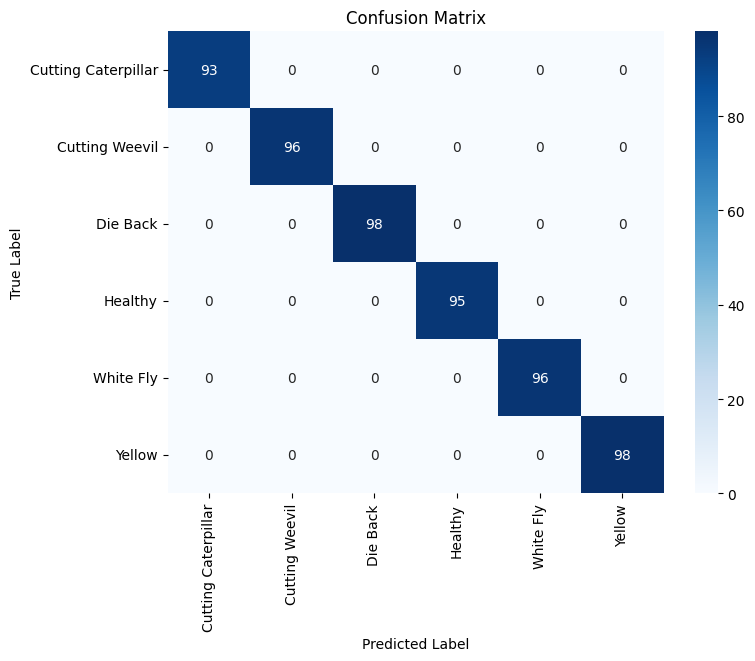

In [26]:
class_names = [
    "Cutting Caterpillar",
    "Cutting Weevil",
    "Die Back",
    "Healthy",
    "White Fly",
    "Yellow"
]

evaluate_model(model, test_loader, class_names)

In [16]:
len(set(train_paths) & set(test_paths))

0

In [17]:
print(len(test_dataset))

576


In [18]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

2686
576
576


In [27]:
set_train = set(train_paths)
set_test = set(test_paths)

print("Overlap:", len(set_train & set_test))
# 0 means no leakage, it checks if any image is both in train and test image set.

Overlap: 0


In [24]:
print(len(test_loader.dataset))

576


In [25]:
from collections import Counter

print(Counter(test_labels))

Counter({2: 98, 5: 98, 1: 96, 4: 96, 3: 95, 0: 93})
